# 不動産投資シミュレーター（年次キャッシュフロー分析）

## 目的
単一物件の長期保有における **キャッシュフロー・税引前／税引後収益性・元利返済・売却時損益** を
年次ベースで分析するためのシミュレーターです。

### 分析フレームワーク
1. **取得時** — 物件価格・取得諸費用・初期修繕・ローン条件から初期エクイティを算出
2. **保有中** — 年次の NOI・借入返済・税金を計算し、税引前／税引後 CF を時系列で管理
3. **売却時** — 出口 Cap Rate から売却価格を推定し、ローン残高返済・譲渡税を考慮した手取りを算出

### 主な前提・簡易化
- **年次ベース**（月次は将来拡張）
- 保有期間は 10〜35 年で可変
- 減価償却は **建物部分のみ・定額法**
- 所得税の欠損繰越は **なし**（簡易版）
- Depreciation Recapture は **簡易版**（コメントで留保）
- 大規模修繕 (Capex) は NOI には含めず、キャッシュフロー上で別途管理

In [20]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from copy import deepcopy

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

# --- matplotlib 日本語フォント設定（環境に応じて変更） ---
try:
    import matplotlib
    matplotlib.rcParams["font.family"] = "sans-serif"
    # 日本語フォント候補（環境に応じて存在するものが使われる）
    matplotlib.rcParams["font.sans-serif"] = [
        "IPAexGothic", "Noto Sans CJK JP", "Yu Gothic",
        "Hiragino Sans", "DejaVu Sans",
    ]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 基本前提条件の入力

以下のパラメータ辞書を編集してシミュレーション条件を設定します。
金額単位は **円** を想定していますが、通貨に依存しない設計です。

| カテゴリ | パラメータ | 説明 |
|---------|----------|------|
| 物件取得 | `purchase_price` | 物件価格 |
| | `land_value` / `building_value` | 土地／建物内訳 |
| | `acquisition_cost_rate` | 取得諸費用率（仲介・登記・税等） |
| | `initial_capex` | 初期修繕・リノベ費用 |
| | `hold_period_years` | 保有年数 |
| 収入 | `initial_gross_rent` | 初年度満室想定賃料 |
| | `vacancy_rate` | 空室率 |
| | `rent_growth_rate` | 賃料成長率（年率） |
| 費用 | `initial_operating_expenses` | 初年度運営費（管理費等） |
| | `capex_schedule` | 大規模修繕スケジュール `{年: 金額}` |
| 借入 | `ltv` | Loan-to-Value |
| | `amortization_type` | `"equal_payment"` or `"interest_only_then_amortizing"` |
| 税金 | `income_tax_rate` | 実効税率（保有中） |
| | `capital_gains_tax_rate` | 譲渡税率（売却時） |

In [21]:
# %%
# ============================================================
#  入力パラメータ
# ============================================================
params = {
    # --- 物件取得 ---
    "purchase_price":          100_000_000,   # 物件価格
    "land_value":               40_000_000,   # 土地価格
    "building_value":           60_000_000,   # 建物価格
    "acquisition_cost_rate":          0.07,   # 取得諸費用率 (7%)
    "initial_capex":             2_000_000,   # 初期修繕費
    "hold_period_years":                20,   # 保有年数

    # --- 賃料・収入 ---
    "initial_gross_rent":        8_400_000,   # 初年度満室想定賃料
    "vacancy_rate":                  0.05,    # 空室率 (5%)
    "rent_growth_rate":             0.005,    # 賃料成長率 (0.5%/年)
    "other_income":                200_000,   # その他収入（駐車場等）
    "other_income_growth_rate":      0.00,    # その他収入成長率

    # --- 運営費 ---
    "initial_operating_expenses": 1_000_000,  # 初年度運営費
    "opex_growth_rate":               0.01,   # 運営費上昇率 (1%/年)
    "property_tax":                900_000,   # 固定資産税・都市計画税
    "property_tax_growth_rate":      0.005,   # 税負担上昇率
    "repair_cost":                 300_000,   # 初年度経常修繕費
    "repair_growth_rate":             0.02,   # 修繕費上昇率 (2%/年)
    "capex_schedule": {                       # 大規模修繕スケジュール
        5:  1_000_000,
        10: 3_000_000,
        15: 1_500_000,
    },

    # --- 借入 ---
    "ltv":                           0.80,    # LTV (80%)
    "interest_rate":                 0.02,    # 金利 (2.0%)
    "loan_term_years":                 30,    # 借入年数
    "amortization_type":   "equal_payment",   # "equal_payment" / "interest_only_then_amortizing"
    "io_years":                         0,    # Interest Only 期間（年）

    # --- 減価償却 ---
    "building_useful_life_years":      22,    # 建物耐用年数
    "depreciation_method":  "straight_line",  # 定額法

    # --- 売却 ---
    "exit_cap_rate":                 0.05,    # 出口 Cap Rate
    "closing_cost_on_sale_rate":    0.035,    # 売却時諸費用率 (3.5%)
    # NOTE: 売却価格は「保有最終年 NOI / exit_cap_rate」で算出（前提を明示）
    # 将来的には価格成長率ベースの出口計算も追加予定

    # --- 税金 ---
    "income_tax_rate":               0.30,    # 保有中の実効税率 (30%)
    "capital_gains_tax_rate":        0.20,    # 売却時の譲渡税率 (20%)
}

print("パラメータ設定完了")
print(f"  物件価格: {params['purchase_price']:,.0f} 円")
print(f"  LTV: {params['ltv']:.0%}  →  借入額: {params['purchase_price'] * params['ltv']:,.0f} 円")
print(f"  保有期間: {params['hold_period_years']} 年")

パラメータ設定完了
  物件価格: 100,000,000 円
  LTV: 80%  →  借入額: 80,000,000 円
  保有期間: 20 年


## 年次収入・NOI 計算

各年の収入・費用を以下のルールで計算します。

**収入側：**
$$
\text{Gross Rent}_t = \text{initial\_gross\_rent} \times (1 + \text{rent\_growth\_rate})^{t-1}
$$
$$
\text{EGI}_t = \text{Gross Rent}_t \times (1 - \text{vacancy\_rate}) + \text{Other Income}_t
$$

**費用側：**
$$
\text{NOI}_t = \text{EGI}_t - \text{OpEx}_t - \text{Property Tax}_t - \text{Repair}_t
$$

> **注意**: 大規模修繕 (Capex) は NOI には含めません。BTCF 計算時に別途控除します。

In [22]:
# %%
def build_revenue_schedule(params):
    """年次収入・NOI スケジュールを構築する。

    Returns:
        pd.DataFrame: year, gross_rent, vacancy_loss, other_income, egi,
                       operating_expenses, property_tax, repair_cost, capex, noi
    """
    hold = params["hold_period_years"]
    records = []

    for y in range(1, hold + 1):
        t = y - 1  # 成長率の指数（初年度 = 0）

        gross_rent = params["initial_gross_rent"] * (1 + params["rent_growth_rate"]) ** t
        vacancy_loss = gross_rent * params["vacancy_rate"]
        other_inc = params["other_income"] * (1 + params["other_income_growth_rate"]) ** t
        egi = gross_rent - vacancy_loss + other_inc

        opex = params["initial_operating_expenses"] * (1 + params["opex_growth_rate"]) ** t
        ptax = params["property_tax"] * (1 + params["property_tax_growth_rate"]) ** t
        repair = params["repair_cost"] * (1 + params["repair_growth_rate"]) ** t
        capex = params.get("capex_schedule", {}).get(y, 0)

        # NOI = EGI - OpEx - Property Tax - Repair（Capex は含まない）
        noi = egi - opex - ptax - repair

        records.append({
            "year": y,
            "gross_rent": gross_rent,
            "vacancy_loss": vacancy_loss,
            "other_income": other_inc,
            "egi": egi,
            "operating_expenses": opex,
            "property_tax": ptax,
            "repair_cost": repair,
            "capex": capex,
            "noi": noi,
        })

    return pd.DataFrame(records)

# 動作確認
_rev = build_revenue_schedule(params)
print(f"Year 1 NOI: {_rev.loc[0, 'noi']:,.0f}")
print(f"Year {params['hold_period_years']} NOI: {_rev.iloc[-1]['noi']:,.0f}")

Year 1 NOI: 5,980,000
Year 20 NOI: 6,338,590


## 借入返済スケジュール

元利均等返済 (equal_payment) の場合の年次返済額:

$$
\text{PMT} = P \times \frac{r(1+r)^n}{(1+r)^n - 1}
$$

- $P$: 借入額 = `purchase_price` × `ltv`
- $r$: 年利率
- $n$: 借入期間（年）

`interest_only_then_amortizing` の場合は、IO 期間中は利息のみ支払い、
その後残りの期間で元利均等返済に移行します。

In [23]:
# %%
def _calc_pmt(principal, rate, periods):
    """元利均等返済の年間返済額を計算する。"""
    if rate == 0:
        return principal / periods
    return principal * rate * (1 + rate) ** periods / ((1 + rate) ** periods - 1)


def build_loan_schedule(params):
    """借入返済スケジュールを構築する。

    対応する返済方式:
      - "equal_payment": 元利均等返済
      - "interest_only_then_amortizing": IO 期間後に元利均等返済

    Returns:
        pd.DataFrame: year, interest, principal, debt_service, loan_balance_end
    """
    loan_amount = params["purchase_price"] * params["ltv"]
    rate = params["interest_rate"]
    n = params["loan_term_years"]
    hold = params["hold_period_years"]
    amort_type = params.get("amortization_type", "equal_payment")
    io_years = params.get("io_years", 0)

    records = []
    balance = loan_amount
    annual_payment = None  # 元利均等返済額（amortizing 期間開始時に確定）

    for y in range(1, hold + 1):
        # ローン完済後
        if balance <= 0 or y > n:
            records.append({
                "year": y, "interest": 0.0, "principal": 0.0,
                "debt_service": 0.0, "loan_balance_end": 0.0,
            })
            continue

        interest = balance * rate

        # IO 期間中
        if amort_type == "interest_only_then_amortizing" and y <= io_years:
            principal_paid = 0.0
            ds = interest
        else:
            # 初回 amortizing 年に返済額を確定
            if annual_payment is None:
                if amort_type == "equal_payment":
                    annual_payment = _calc_pmt(loan_amount, rate, n)
                else:
                    # IO→amortizing 移行時の残期間で再計算
                    remaining = n - io_years
                    annual_payment = _calc_pmt(balance, rate, remaining)
            principal_paid = annual_payment - interest
            ds = annual_payment

        balance = max(balance - principal_paid, 0.0)

        records.append({
            "year": y,
            "interest": interest,
            "principal": principal_paid,
            "debt_service": ds,
            "loan_balance_end": balance,
        })

    return pd.DataFrame(records)

# 動作確認
_loan = build_loan_schedule(params)
_loan_amt = params["purchase_price"] * params["ltv"]
print(f"借入額: {_loan_amt:,.0f}")
print(f"年間返済額 (Year 1): {_loan.loc[0, 'debt_service']:,.0f}")
print(f"Year {params['hold_period_years']} ローン残高: {_loan.iloc[-1]['loan_balance_end']:,.0f}")

借入額: 80,000,000
年間返済額 (Year 1): 3,571,994
Year 20 ローン残高: 32,085,738


## 減価償却

- **対象**: 建物部分 (`building_value`) のみ
- **方式**: 定額法 (straight-line)
- **年間償却額** = `building_value` / `building_useful_life_years`
- 耐用年数を超えた年は償却額 = 0

> **簡易化**: 取得諸費用・初期修繕・大規模修繕の資本化・追加償却は未対応（将来拡張予定）

In [24]:
# %%
def build_depreciation_schedule(params):
    """建物の定額法減価償却スケジュールを構築する。

    Returns:
        pd.DataFrame: year, depreciation
    """
    bv = params["building_value"]
    life = params["building_useful_life_years"]
    hold = params["hold_period_years"]

    annual_dep = bv / life

    records = []
    for y in range(1, hold + 1):
        dep = annual_dep if y <= life else 0.0
        records.append({"year": y, "depreciation": dep})

    return pd.DataFrame(records)

# 動作確認
_dep = build_depreciation_schedule(params)
print(f"年間償却額: {_dep.loc[0, 'depreciation']:,.0f}")
print(f"累計償却額 ({params['hold_period_years']}年): {_dep['depreciation'].sum():,.0f}")

年間償却額: 2,727,273
累計償却額 (20年): 54,545,455


## 税引前・税引後キャッシュフロー

### BTCF（税引前キャッシュフロー）
$$
\text{BTCF}_t = \text{NOI}_t - \text{Debt Service}_t - \text{Capex}_t
$$

### ATCF（税引後キャッシュフロー）
$$
\text{Taxable Income}_t = \text{NOI}_t - \text{Interest}_t - \text{Depreciation}_t
$$
$$
\text{Tax}_t = \max(\text{Taxable Income}_t, 0) \times \text{income\_tax\_rate}
$$
$$
\text{ATCF}_t = \text{BTCF}_t - \text{Tax}_t
$$

> **前提**:
> - 欠損繰越なし（課税所得がマイナスの年は Tax = 0）
> - 他の所得との損益通算なし（簡易版）

## 売却年の出口計算

保有最終年に物件を売却する想定で以下を計算します。

### 売却価格
$$
\text{Sale Price} = \frac{\text{Terminal NOI}}{\text{exit\_cap\_rate}}
$$

**Terminal NOI** = 保有最終年の NOI を使用（前提）

> 将来的には「翌年 NOI（フォワード NOI）」や「価格成長率ベース」での出口推定も追加予定

### 売却時キャッシュフロー
1. **Net Sale Price** = Sale Price − 売却諸費用
2. **BT Sale Proceeds** = Net Sale Price − ローン残高
3. **Taxable Gain** = Net Sale Price − Adjusted Basis
   - Adjusted Basis = Purchase Price + 取得諸費用 + 初期修繕 + 累計 Capex − 累計減価償却
4. **Capital Gains Tax** = max(Taxable Gain, 0) × `capital_gains_tax_rate`
5. **Net Sale Proceeds** = BT Sale Proceeds − Capital Gains Tax

> **Depreciation Recapture**: 日本の税制では譲渡所得に含まれるため、ここでは簡易的に
> 全体を `capital_gains_tax_rate` で課税しています。精緻化は将来対応。

## 統合シミュレーション関数

上記の個別関数を統合し、全期間のキャッシュフロー表と要約情報を返す関数です。

In [25]:
# %%
def run_simulation(params):
    """統合シミュレーションを実行する。

    Returns:
        df (pd.DataFrame): 年次キャッシュフローテーブル
        summary (dict): 取得・売却に関する要約情報
    """
    # --- 個別スケジュール構築 ---
    rev_df = build_revenue_schedule(params)
    loan_df = build_loan_schedule(params)
    dep_df = build_depreciation_schedule(params)

    # --- 結合 ---
    df = rev_df.merge(loan_df, on="year").merge(dep_df, on="year")

    # --- BTCF ---
    df["btcf"] = df["noi"] - df["debt_service"] - df["capex"]

    # --- 課税所得・税金 ---
    df["taxable_income"] = df["noi"] - df["interest"] - df["depreciation"]
    df["tax"] = df["taxable_income"].clip(lower=0) * params["income_tax_rate"]

    # --- ATCF ---
    df["atcf"] = df["btcf"] - df["tax"]

    # --- 初期投資額 ---
    total_acquisition = (
        params["purchase_price"] * (1 + params["acquisition_cost_rate"])
        + params["initial_capex"]
    )
    loan_amount = params["purchase_price"] * params["ltv"]
    equity_invested = total_acquisition - loan_amount

    # =========================================================
    #  売却計算（保有最終年）
    # =========================================================
    hold = params["hold_period_years"]
    terminal_noi = df.loc[df["year"] == hold, "noi"].values[0]

    sale_price = terminal_noi / params["exit_cap_rate"]
    selling_costs = sale_price * params["closing_cost_on_sale_rate"]
    net_sale_price = sale_price - selling_costs

    loan_balance_at_sale = df.loc[df["year"] == hold, "loan_balance_end"].values[0]
    bt_sale_proceeds = net_sale_price - loan_balance_at_sale

    # --- 売却時課税 ---
    accumulated_dep = df["depreciation"].sum()
    total_capex_spent = df["capex"].sum()

    # Adjusted Basis = 取得原価 + 諸費用 + 初期修繕 + 累計Capex − 累計減価償却
    cost_basis = (
        params["purchase_price"]
        + params["purchase_price"] * params["acquisition_cost_rate"]
        + params["initial_capex"]
        + total_capex_spent
    )
    adjusted_basis = cost_basis - accumulated_dep

    taxable_gain = net_sale_price - adjusted_basis
    capital_gains_tax = max(taxable_gain, 0) * params["capital_gains_tax_rate"]

    net_sale_proceeds = bt_sale_proceeds - capital_gains_tax

    # --- DataFrame に売却データを反映 ---
    df["sale_proceeds_net"] = 0.0
    df.loc[df["year"] == hold, "sale_proceeds_net"] = net_sale_proceeds

    # --- Total Equity Cash Flow ---
    df["total_equity_cf"] = df["atcf"] + df["sale_proceeds_net"]

    # --- 累積 CF ---
    df["cumulative_atcf"] = df["atcf"].cumsum()
    df["cumulative_equity_cf"] = df["total_equity_cf"].cumsum()

    # --- 初期エクイティ投下を累積に反映（表示用） ---
    df["cumulative_equity_cf_with_initial"] = df["cumulative_equity_cf"] - equity_invested

    # --- Summary ---
    summary = {
        "total_acquisition_cost": total_acquisition,
        "loan_amount": loan_amount,
        "equity_invested": equity_invested,
        "sale_price": sale_price,
        "selling_costs": selling_costs,
        "net_sale_price": net_sale_price,
        "loan_balance_at_sale": loan_balance_at_sale,
        "bt_sale_proceeds": bt_sale_proceeds,
        "cost_basis": cost_basis,
        "accumulated_depreciation": accumulated_dep,
        "adjusted_basis": adjusted_basis,
        "taxable_gain": taxable_gain,
        "capital_gains_tax": capital_gains_tax,
        "net_sale_proceeds": net_sale_proceeds,
        "terminal_noi": terminal_noi,
    }

    return df, summary

print("run_simulation 関数を定義しました。")

run_simulation 関数を定義しました。


## 投資指標の計算

| 指標 | 定義 |
|------|------|
| **Cap Rate** | Year 1 NOI / Purchase Price |
| **Cash-on-Cash** | BTCF / Equity Invested |
| **DSCR** | NOI / Debt Service |
| **Equity IRR** | Equity CF 系列の内部収益率 |
| **Project IRR** | 全投資額ベース（レバ前・税前）の内部収益率 |
| **Equity Multiple** | 累計 Equity CF / Equity Invested |

In [26]:
# %%
def _compute_irr(cashflows, tol=1e-10, max_iter=1000):
    """IRR を二分法で計算する。

    Args:
        cashflows: [CF_0, CF_1, ..., CF_n] のリスト
    Returns:
        float or None: IRR（見つからない場合は None）
    """
    def npv(rate):
        return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

    low, high = -0.50, 2.00
    npv_low, npv_high = npv(low), npv(high)

    if npv_low * npv_high > 0:
        return None  # 解なし

    for _ in range(max_iter):
        mid = (low + high) / 2.0
        npv_mid = npv(mid)
        if abs(npv_mid) < tol or (high - low) / 2 < tol:
            return mid
        if npv_low * npv_mid < 0:
            high = mid
            npv_high = npv_mid
        else:
            low = mid
            npv_low = npv_mid

    return (low + high) / 2.0


def compute_metrics(params, df, summary):
    """主要投資指標を計算する。

    Returns:
        metrics (dict): 各指標の値
        df (pd.DataFrame): cash_on_cash, dscr 列を追加した DataFrame
    """
    equity = summary["equity_invested"]
    hold = params["hold_period_years"]

    # --- Cap Rate ---
    year1_noi = df.loc[df["year"] == 1, "noi"].values[0]
    cap_rate = year1_noi / params["purchase_price"]

    # --- Cash-on-Cash (各年) ---
    df["cash_on_cash"] = df["btcf"] / equity

    # --- DSCR (各年) ---
    df["dscr"] = df.apply(
        lambda r: r["noi"] / r["debt_service"] if r["debt_service"] > 0 else np.inf,
        axis=1,
    )

    # --- Equity IRR ---
    equity_cfs = [-equity] + df["total_equity_cf"].tolist()
    equity_irr = _compute_irr(equity_cfs)

    # --- Project IRR (unlevered, pre-tax) ---
    project_cfs = [-summary["total_acquisition_cost"]]
    for _, row in df.iterrows():
        cf = row["noi"] - row["capex"]
        if row["year"] == hold:
            cf += summary["net_sale_price"]  # 売却手取り（ローン返済前・譲渡税前）
        project_cfs.append(cf)
    project_irr = _compute_irr(project_cfs)

    # --- Equity Multiple ---
    total_received = df["total_equity_cf"].sum()
    equity_multiple = total_received / equity

    metrics = {
        "cap_rate": cap_rate,
        "avg_cash_on_cash": df["cash_on_cash"].mean(),
        "equity_irr": equity_irr,
        "project_irr": project_irr,
        "equity_multiple": equity_multiple,
        "min_dscr": df["dscr"].replace(np.inf, np.nan).min(),
        "avg_dscr": df["dscr"].replace(np.inf, np.nan).mean(),
    }

    return metrics, df

print("compute_metrics 関数を定義しました。")

compute_metrics 関数を定義しました。


## シミュレーション実行

サンプルパラメータでシミュレーションを実行し、結果を確認します。

In [27]:
# %%
# --- シミュレーション実行 ---
df, summary = run_simulation(params)
metrics, df = compute_metrics(params, df, summary)

# --- 投資概要の表示 ---
print("=" * 60)
print("  投資概要")
print("=" * 60)
print(f"  物件価格:         {params['purchase_price']:>15,.0f} 円")
print(f"  取得総額:         {summary['total_acquisition_cost']:>15,.0f} 円")
print(f"  借入額:           {summary['loan_amount']:>15,.0f} 円")
print(f"  自己資金:         {summary['equity_invested']:>15,.0f} 円")
print(f"  保有年数:         {params['hold_period_years']:>15} 年")
print()
print(f"  Cap Rate:         {metrics['cap_rate']:>14.2%}")
print(f"  Avg Cash-on-Cash: {metrics['avg_cash_on_cash']:>14.2%}")
print(f"  Equity IRR:       {metrics['equity_irr']:>14.2%}" if metrics["equity_irr"] else "  Equity IRR:       N/A")
print(f"  Project IRR:      {metrics['project_irr']:>14.2%}" if metrics["project_irr"] else "  Project IRR:      N/A")
print(f"  Equity Multiple:  {metrics['equity_multiple']:>14.2f}x")
print(f"  Min DSCR:         {metrics['min_dscr']:>14.2f}")
print(f"  Avg DSCR:         {metrics['avg_dscr']:>14.2f}")
print()
print("--- 売却 ---")
print(f"  Terminal NOI:     {summary['terminal_noi']:>15,.0f} 円")
print(f"  売却価格:         {summary['sale_price']:>15,.0f} 円")
print(f"  売却諸費用:       {summary['selling_costs']:>15,.0f} 円")
print(f"  Net Sale Price:   {summary['net_sale_price']:>15,.0f} 円")
print(f"  ローン残高:       {summary['loan_balance_at_sale']:>15,.0f} 円")
print(f"  譲渡税:           {summary['capital_gains_tax']:>15,.0f} 円")
print(f"  売却手取り:       {summary['net_sale_proceeds']:>15,.0f} 円")

  投資概要
  物件価格:             100,000,000 円
  取得総額:             109,000,000 円
  借入額:                80,000,000 円
  自己資金:              29,000,000 円
  保有年数:                      20 年

  Cap Rate:                  5.98%
  Avg Cash-on-Cash:          7.98%
  Equity IRR:                9.01%
  Project IRR:               5.72%
  Equity Multiple:            3.81x
  Min DSCR:                   1.67
  Avg DSCR:                   1.72

--- 売却 ---
  Terminal NOI:           6,338,590 円
  売却価格:             126,771,793 円
  売却諸費用:             4,437,013 円
  Net Sale Price:       122,334,781 円
  ローン残高:            32,085,738 円
  譲渡税:                12,476,047 円
  売却手取り:            77,772,996 円


## 結果テーブル

年次キャッシュフローの詳細テーブルを表示します。

In [28]:
# %%
# --- 表示用 DataFrame ---
display_cols = [
    "year", "gross_rent", "vacancy_loss", "egi",
    "operating_expenses", "property_tax", "repair_cost", "noi",
    "capex", "interest", "principal", "debt_service",
    "depreciation", "taxable_income", "tax",
    "btcf", "atcf", "loan_balance_end",
    "sale_proceeds_net", "total_equity_cf",
]

display_names = {
    "year": "Year",
    "gross_rent": "Gross Rent",
    "vacancy_loss": "Vacancy Loss",
    "egi": "EGI",
    "operating_expenses": "OpEx",
    "property_tax": "Property Tax",
    "repair_cost": "Repair",
    "noi": "NOI",
    "capex": "Capex",
    "interest": "Interest",
    "principal": "Principal",
    "debt_service": "Debt Service",
    "depreciation": "Depreciation",
    "taxable_income": "Taxable Income",
    "tax": "Tax",
    "btcf": "BTCF",
    "atcf": "ATCF",
    "loan_balance_end": "Loan Balance",
    "sale_proceeds_net": "Sale Proceeds",
    "total_equity_cf": "Total Equity CF",
}

df_display = df[display_cols].rename(columns=display_names).copy()
df_display = df_display.set_index("Year")

# 数値フォーマット
df_display

,Gross Rent,Vacancy Loss,EGI,OpEx,Property Tax,Repair,NOI,Capex,Interest,Principal,Debt Service,Depreciation,Taxable Income,Tax,BTCF,ATCF,Loan Balance,Sale Proceeds,Total Equity CF
Year,,,,,,,,,,,,,,,,,,,
1,"8,400,000","420,000","8,180,000","1,000,000","900,000","300,000","5,980,000",0,"1,600,000","1,971,994","3,571,994","2,727,273","1,652,727","495,818","2,408,006","1,912,188","78,028,006",0,"1,912,188"
2,"8,442,000","422,100","8,219,900","1,010,000","904,500","306,000","5,999,400",0,"1,560,560","2,011,434","3,571,994","2,727,273","1,711,567","513,470","2,427,406","1,913,936","76,016,573",0,"1,913,936"
3,"8,484,210","424,210","8,259,999","1,020,100","909,022","312,120","6,018,757",0,"1,520,331","2,051,662","3,571,994","2,727,273","1,771,153","531,346","2,446,763","1,915,417","73,964,910",0,"1,915,417"
4,"8,526,631","426,332","8,300,299","1,030,301","913,568","318,362","6,038,068",0,"1,479,298","2,092,696","3,571,994","2,727,273","1,831,498","549,449","2,466,075","1,916,625","71,872,215",0,"1,916,625"
5,"8,569,264","428,463","8,340,801","1,040,604","918,135","324,730","6,057,332",1000000,"1,437,444","2,134,549","3,571,994","2,727,273","1,892,615","567,784","1,485,338","917,554","69,737,665",0,"917,554"
6,"8,612,111","430,606","8,381,505","1,051,010","922,726","331,224","6,076,545",0,"1,394,753","2,177,240","3,571,994","2,727,273","1,954,519","586,356","2,504,551","1,918,195","67,560,425",0,"1,918,195"
7,"8,655,171","432,759","8,422,413","1,061,520","927,340","337,849","6,095,704",0,"1,351,208","2,220,785","3,571,994","2,727,273","2,017,223","605,167","2,523,710","1,918,543","65,339,639",0,"1,918,543"
8,"8,698,447","434,922","8,463,525","1,072,135","931,976","344,606","6,114,807",0,"1,306,793","2,265,201","3,571,994","2,727,273","2,080,742","624,222","2,542,813","1,918,591","63,074,438",0,"1,918,591"
9,"8,741,939","437,097","8,504,842","1,082,857","936,636","351,498","6,133,851",0,"1,261,489","2,310,505","3,571,994","2,727,273","2,145,090","643,527","2,561,858","1,918,331","60,763,933",0,"1,918,331"


In [29]:
# %%
# --- 年次指標テーブル ---
indicators = df[["year", "cash_on_cash", "dscr"]].copy()
indicators = indicators.rename(columns={
    "year": "Year",
    "cash_on_cash": "Cash-on-Cash",
    "dscr": "DSCR",
})
indicators = indicators.set_index("Year")
indicators.style.format({"Cash-on-Cash": "{:.2%}", "DSCR": "{:.2f}"})

,Cash-on-Cash,DSCR
Year,,
1,8.30%,1.67
2,8.37%,1.68
3,8.44%,1.68
4,8.50%,1.69
5,5.12%,1.70
6,8.64%,1.70
7,8.70%,1.71
8,8.77%,1.71
9,8.83%,1.72


## グラフ表示

### 1. NOI / Debt Service / BTCF / ATCF の年次推移
### 2. 累積 Equity Cash Flow
### 3. Loan Balance の推移

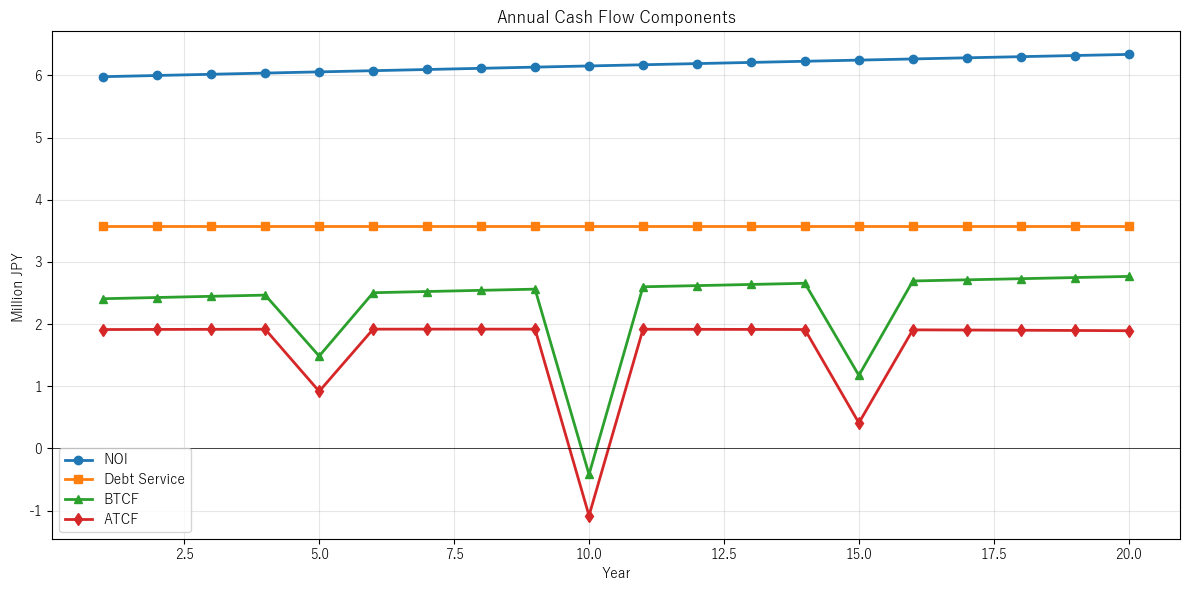

In [30]:
# %%
fig, ax = plt.subplots(figsize=(12, 6))

years = df["year"]
ax.plot(years, df["noi"] / 1e6, marker="o", label="NOI", linewidth=2)
ax.plot(years, df["debt_service"] / 1e6, marker="s", label="Debt Service", linewidth=2)
ax.plot(years, df["btcf"] / 1e6, marker="^", label="BTCF", linewidth=2)
ax.plot(years, df["atcf"] / 1e6, marker="d", label="ATCF", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Annual Cash Flow Components")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

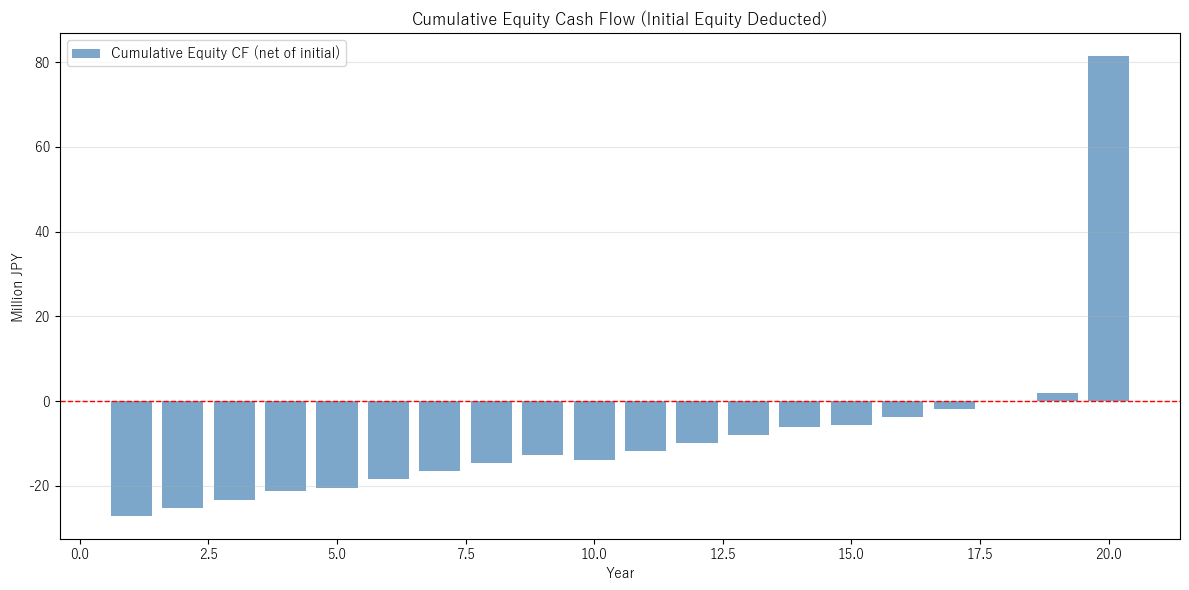

In [31]:
# %%
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df["year"], df["cumulative_equity_cf_with_initial"] / 1e6,
       color="steelblue", alpha=0.7, label="Cumulative Equity CF (net of initial)")
ax.axhline(y=0, color="red", linewidth=1, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Cumulative Equity Cash Flow (Initial Equity Deducted)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

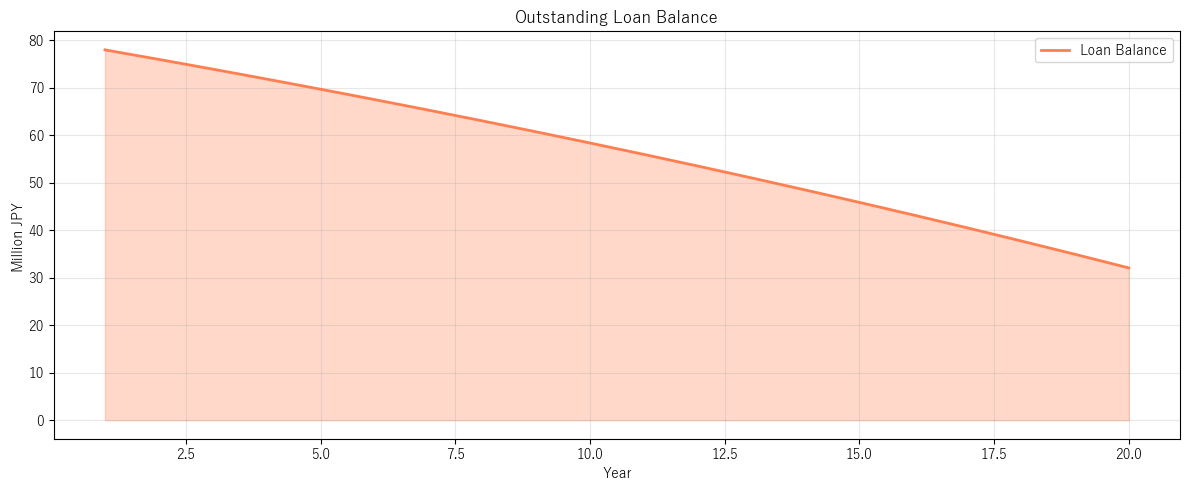

In [32]:
# %%
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df["year"], df["loan_balance_end"] / 1e6, alpha=0.3, color="coral")
ax.plot(df["year"], df["loan_balance_end"] / 1e6, color="coral", linewidth=2, label="Loan Balance")

ax.set_xlabel("Year")
ax.set_ylabel("Million JPY")
ax.set_title("Outstanding Loan Balance")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## シナリオ分析（感応度分析）

パラメータを変化させた場合の **Equity IRR** や **累積 ATCF** を比較します。

1. **賃料成長率** を変えた場合の Equity IRR
2. **出口 Cap Rate** を変えた場合の Equity IRR
3. **修繕費成長率** を変えた場合の累積 ATCF

In [33]:
# %%
def run_scenario(base_params, overrides):
    """パラメータを一部変更してシミュレーションを実行する。

    Args:
        base_params: ベースパラメータ dict
        overrides: 上書きする {key: value} の dict

    Returns:
        df, summary, metrics
    """
    p = deepcopy(base_params)
    p.update(overrides)
    df_s, summary_s = run_simulation(p)
    metrics_s, df_s = compute_metrics(p, df_s, summary_s)
    return df_s, summary_s, metrics_s

print("run_scenario ヘルパー関数を定義しました。")

run_scenario ヘルパー関数を定義しました。


=== Rent Growth Rate Sensitivity ===
rent_growth_rate  equity_irr  equity_multiple  cap_rate
           -1.0%       5.02%            2.12x     5.98%
            0.0%       7.81%            3.20x     5.98%
            0.5%       9.01%            3.81x     5.98%
            1.0%      10.11%            4.47x     5.98%
            2.0%      12.11%            5.97x     5.98%


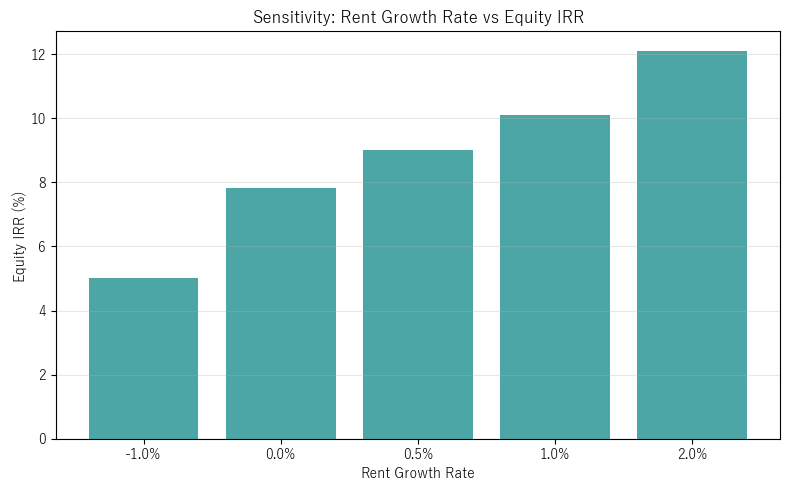

In [34]:
# %%
# --- シナリオ 1: 賃料成長率 vs Equity IRR ---
rent_growth_scenarios = [-0.01, 0.0, 0.005, 0.01, 0.02]
results_rent = []

for rg in rent_growth_scenarios:
    _, _, m = run_scenario(params, {"rent_growth_rate": rg})
    results_rent.append({
        "rent_growth_rate": f"{rg:.1%}",
        "equity_irr": m["equity_irr"],
        "equity_multiple": m["equity_multiple"],
        "cap_rate": m["cap_rate"],
    })

df_rent_scenario = pd.DataFrame(results_rent)
print("=== Rent Growth Rate Sensitivity ===")
print(df_rent_scenario.to_string(index=False, float_format=lambda x: f"{x:.2%}" if abs(x) < 1 else f"{x:.2f}x"))

# グラフ
fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["equity_irr"] if r["equity_irr"] else 0 for r in results_rent]
ax.bar([r["rent_growth_rate"] for r in results_rent], [x * 100 for x in irrs], color="teal", alpha=0.7)
ax.set_xlabel("Rent Growth Rate")
ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Rent Growth Rate vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

=== Exit Cap Rate Sensitivity ===
exit_cap_rate equity_irr  sale_price net_sale_proceeds
         3.5%     10.76% 181,102,562       119,716,349
         4.0%     10.10% 158,464,742       102,239,952
         4.5%      9.52% 140,857,548        88,647,199
         5.0%      9.01% 126,771,793        77,772,996
         5.5%      8.54% 115,247,085        68,875,921
         6.0%      8.12% 105,643,161        61,461,692


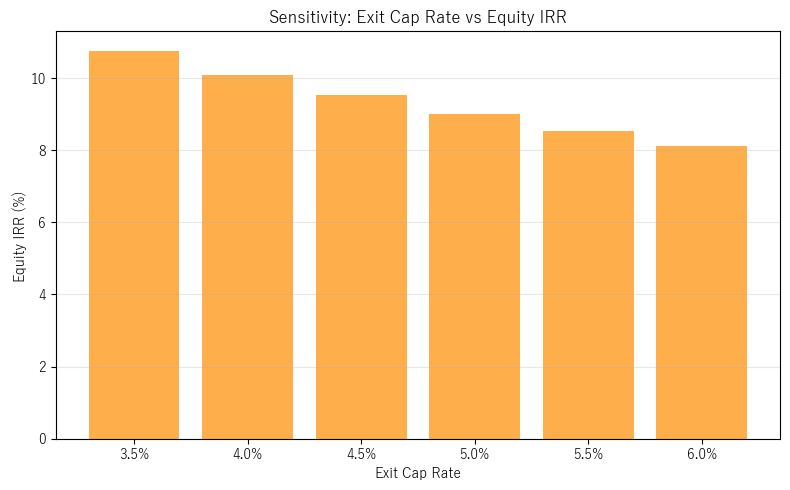

In [35]:
# %%
# --- シナリオ 2: 出口 Cap Rate vs Equity IRR ---
exit_cap_scenarios = [0.035, 0.04, 0.045, 0.05, 0.055, 0.06]
results_exit = []

for ec in exit_cap_scenarios:
    _, s, m = run_scenario(params, {"exit_cap_rate": ec})
    results_exit.append({
        "exit_cap_rate": f"{ec:.1%}",
        "equity_irr": m["equity_irr"],
        "sale_price": s["sale_price"],
        "net_sale_proceeds": s["net_sale_proceeds"],
    })

df_exit_scenario = pd.DataFrame(results_exit)
# フォーマットして表示
df_exit_display = df_exit_scenario.copy()
df_exit_display["equity_irr"] = df_exit_display["equity_irr"].apply(lambda x: f"{x:.2%}" if x else "N/A")
df_exit_display["sale_price"] = df_exit_display["sale_price"].apply(lambda x: f"{x:,.0f}")
df_exit_display["net_sale_proceeds"] = df_exit_display["net_sale_proceeds"].apply(lambda x: f"{x:,.0f}")
print("=== Exit Cap Rate Sensitivity ===")
print(df_exit_display.to_string(index=False))

# グラフ
fig, ax = plt.subplots(figsize=(8, 5))
irrs = [r["equity_irr"] if r["equity_irr"] else 0 for r in results_exit]
ax.bar([r["exit_cap_rate"] for r in results_exit], [x * 100 for x in irrs], color="darkorange", alpha=0.7)
ax.set_xlabel("Exit Cap Rate")
ax.set_ylabel("Equity IRR (%)")
ax.set_title("Sensitivity: Exit Cap Rate vs Equity IRR")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

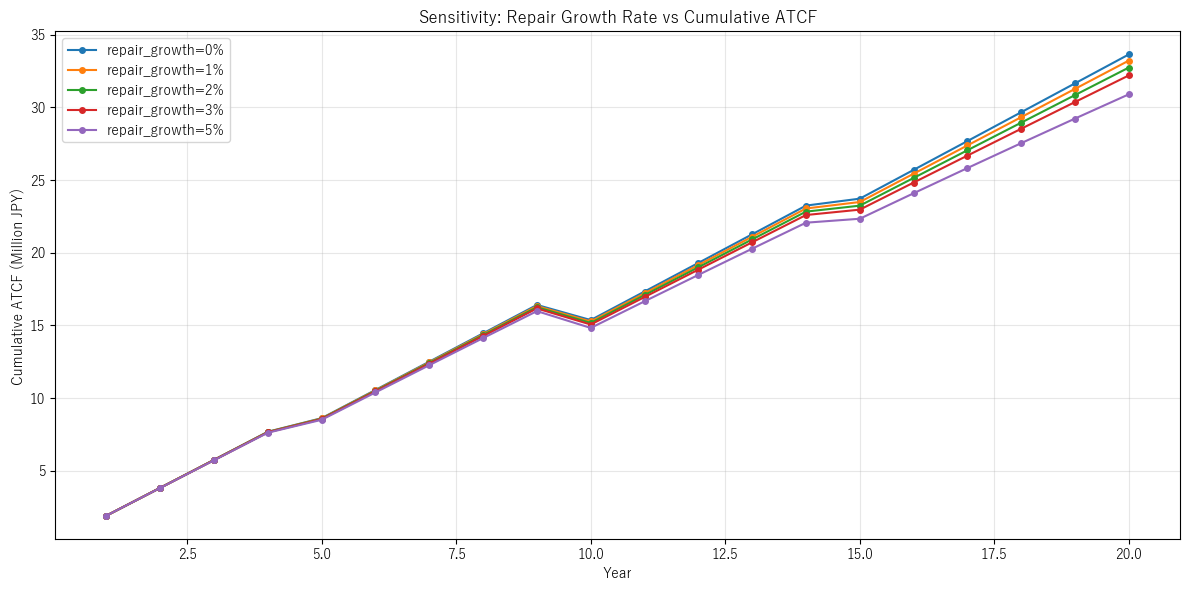

In [36]:
# %%
# --- シナリオ 3: 修繕費成長率 vs 累積ATCF ---
repair_scenarios = [0.0, 0.01, 0.02, 0.03, 0.05]

fig, ax = plt.subplots(figsize=(12, 6))

for rg in repair_scenarios:
    df_s, _, _ = run_scenario(params, {"repair_growth_rate": rg})
    ax.plot(df_s["year"], df_s["cumulative_atcf"] / 1e6,
            marker="o", markersize=4, label=f"repair_growth={rg:.0%}")

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative ATCF (Million JPY)")
ax.set_title("Sensitivity: Repair Growth Rate vs Cumulative ATCF")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 二次元感応度テーブル

賃料成長率 × 出口 Cap Rate の組み合わせで Equity IRR のマトリクスを作成します。

In [37]:
# %%
rent_growth_vals = [-0.005, 0.0, 0.005, 0.01, 0.015]
exit_cap_vals = [0.04, 0.045, 0.05, 0.055, 0.06]

matrix = {}
for rg in rent_growth_vals:
    row = {}
    for ec in exit_cap_vals:
        _, _, m = run_scenario(params, {"rent_growth_rate": rg, "exit_cap_rate": ec})
        irr = m["equity_irr"]
        row[f"Exit {ec:.1%}"] = f"{irr:.2%}" if irr is not None else "N/A"
    matrix[f"Rent {rg:+.1%}"] = row

df_matrix = pd.DataFrame(matrix).T
df_matrix.index.name = "Rent Growth \\ Exit Cap"
print("=== Equity IRR Sensitivity Matrix ===")
df_matrix

=== Equity IRR Sensitivity Matrix ===


,Exit 4.0%,Exit 4.5%,Exit 5.0%,Exit 5.5%,Exit 6.0%
Rent Growth \ Exit Cap,,,,,
Rent -0.5%,7.74%,7.09%,6.50%,5.96%,5.46%
Rent +0.0%,8.97%,8.36%,7.81%,7.32%,6.86%
Rent +0.5%,10.10%,9.52%,9.01%,8.54%,8.12%
Rent +1.0%,11.15%,10.60%,10.11%,9.67%,9.27%
Rent +1.5%,12.14%,11.61%,11.14%,10.72%,10.34%


## 今後の拡張ポイント

### 短期的な改善
- [ ] **月次化**: 年次 → 月次ベースの CF 計算（賃料入金・ローン返済のタイミングを正確に）
- [ ] **IO→amortizing 返済方式のテスト**: `amortization_type="interest_only_then_amortizing"` の検証
- [ ] **複数シナリオの自動比較レポート**: HTML / PDF 出力

### 税務の精緻化
- [ ] **損益通算**: 不動産所得の赤字を他の所得と通算
- [ ] **欠損繰越**: 最大 3 年間の損失繰越
- [ ] **Depreciation Recapture**: 売却時の減価償却戻入課税の精緻計算
- [ ] **法人 vs 個人**: 法人税率・所得税累進税率の切替
- [ ] **消費税**: 建物部分の消費税取扱い
- [ ] **登録免許税・不動産取得税**: 取得時の個別税目

### 収入モデルの高度化
- [ ] **賃料改定モデル**: 契約更新時の賃料変動（ステップレント等）
- [ ] **リーシングコスト**: テナント入替時の仲介手数料・フリーレント
- [ ] **空室率の動的モデル**: 築年数・エリア特性に応じた空室率変動
- [ ] **テナント構成**: 複数テナント・異なる契約条件の管理

### 出口戦略
- [ ] **価格成長率ベースの売却価格**: `sale_price = purchase_price * (1 + growth_rate)^n`
- [ ] **フォワード NOI ベースの Cap Rate 適用**: 翌年 NOI での売却価格推定
- [ ] **売却タイミング最適化**: 各年の売却 IRR を比較

### ポートフォリオ・高度分析
- [ ] **複数物件ポートフォリオ**: 物件間の CF 統合・リスク分散分析
- [ ] **モンテカルロシミュレーション**: 賃料・空室率・金利などの確率的変動
- [ ] **感応度ヒートマップ**: 2 変数の組合せ感応度を可視化
- [ ] **ブレークイーブン分析**: 空室率・金利のブレークイーブンポイント

### 技術的改善
- [ ] **クラス設計**: `Property`, `Loan`, `TaxCalculator` 等のオブジェクト化
- [ ] **設定ファイル**: YAML / JSON ベースのパラメータ管理
- [ ] **Web UI**: Streamlit / Gradio によるインタラクティブダッシュボード
- [ ] **データベース連携**: 過去シミュレーション結果の蓄積・比較